In [ ]:
#https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/problem12.html

In [15]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [26]:
df = pd.read_csv('titanic.csv')
df

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000


In [27]:
df.drop(columns=["Name", "Fare"],axis=1, inplace=True)
df

,Survived,Pclass,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0
...,...,...,...,...,...,...
882,0,2,male,27.0,0,0
883,1,1,female,19.0,0,0
884,0,3,female,7.0,1,2
885,1,1,male,26.0,0,0


In [28]:
df.columns = ["Survived", "Pclass", "Sex", "Age", "Ssa", "Pca"]
df

,Survived,Pclass,Sex,Age,Ssa,Pca
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0
...,...,...,...,...,...,...
882,0,2,male,27.0,0,0
883,1,1,female,19.0,0,0
884,0,3,female,7.0,1,2
885,1,1,male,26.0,0,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  887 non-null    int64  
 1   Pclass    887 non-null    int64  
 2   Sex       887 non-null    object 
 3   Age       887 non-null    float64
 4   Ssa       887 non-null    int64  
 5   Pca       887 non-null    int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 41.7+ KB


In [30]:
df["Sex"] = df["Sex"].map({"female": 0, "male":1})
df

,Survived,Pclass,Sex,Age,Ssa,Pca
0,0,3,1,22.0,1,0
1,1,1,0,38.0,1,0
2,1,3,0,26.0,0,0
3,1,1,0,35.0,1,0
4,0,3,1,35.0,0,0
...,...,...,...,...,...,...
882,0,2,1,27.0,0,0
883,1,1,0,19.0,0,0
884,0,3,0,7.0,1,2
885,1,1,1,26.0,0,0


In [31]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
Ssa         0
Pca         0
dtype: int64

In [32]:
df

,Survived,Pclass,Sex,Age,Ssa,Pca
0,0,3,1,22.0,1,0
1,1,1,0,38.0,1,0
2,1,3,0,26.0,0,0
3,1,1,0,35.0,1,0
4,0,3,1,35.0,0,0
...,...,...,...,...,...,...
882,0,2,1,27.0,0,0
883,1,1,0,19.0,0,0
884,0,3,0,7.0,1,2
885,1,1,1,26.0,0,0


In [33]:
Y = df.Survived
X = df.drop("Survived", axis=1)

In [35]:
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [36]:
tree = DecisionTreeClassifier(max_depth = 2, random_state=42)
tree.fit(x_train,y_train)


DecisionTreeClassifier(max_depth=2, random_state=42)

In [37]:
y_predict = tree.predict(x_test)
accurracy = accuracy_score(y_test, y_predict)
print("Accuracy : ", accurracy )

Accuracy :  0.7247191011235955


Text(0.5, 1.0, 'Importancia de las feature')

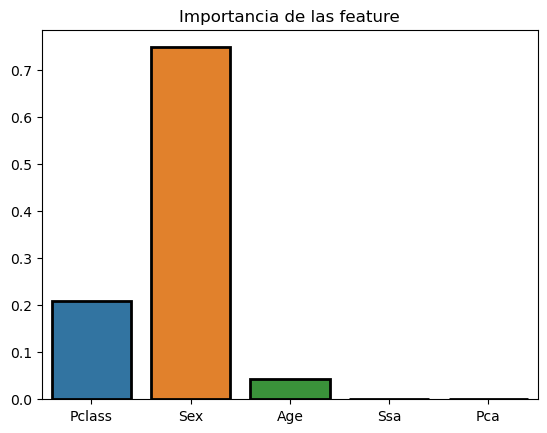

In [40]:
import seaborn as sns

importance = tree.feature_importances_
columns = X.columns
sns.barplot(x= columns, y = importance, edgecolor = "black", linewidth = 2)
plt.title("Importancia de las feature")


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  887 non-null    int64  
 1   Pclass    887 non-null    int64  
 2   Sex       887 non-null    int64  
 3   Age       887 non-null    float64
 4   Ssa       887 non-null    int64  
 5   Pca       887 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 41.7 KB


In [4]:
# https://www.kaggle.com/datasets/elikplim/car-evaluation-data-set

In [41]:
df = pd.read_csv("car_evaluation.csv")
df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [42]:
df.columns = ["Price", "Maint", "Doors", "Persons", "lug_boot", "Safety", "Decision"]
df

,Price,Maint,Doors,Persons,lug_boot,Safety,Decision
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Price     1727 non-null   object
 1   Maint     1727 non-null   object
 2   Doors     1727 non-null   object
 3   Persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   Safety    1727 non-null   object
 6   Decision  1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [44]:
df.isnull().sum()

Price       0
Maint       0
Doors       0
Persons     0
lug_boot    0
Safety      0
Decision    0
dtype: int64

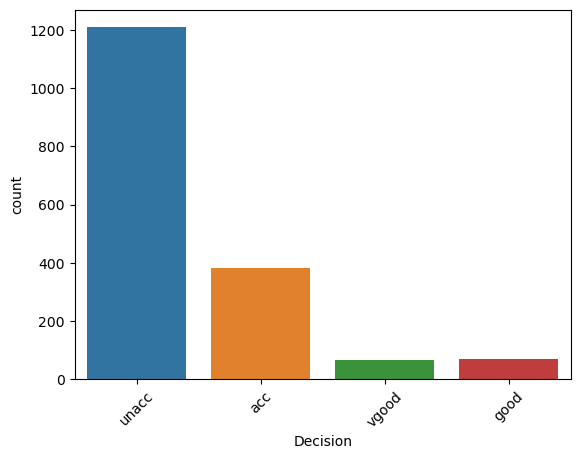

In [45]:
sns.countplot(x="Decision", data=df)
plt.xticks(rotation = 45)
plt.show()

In [48]:
df["Decision"].value_counts()

Decision
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [50]:
x = df.drop("Decision", axis = 1)
y = df.Decision

In [51]:
x

,Price,Maint,Doors,Persons,lug_boot,Safety
0,vhigh,vhigh,2,2,small,med
1,vhigh,vhigh,2,2,small,high
2,vhigh,vhigh,2,2,med,low
3,vhigh,vhigh,2,2,med,med
4,vhigh,vhigh,2,2,med,high
...,...,...,...,...,...,...
1722,low,low,5more,more,med,med
1723,low,low,5more,more,med,high
1724,low,low,5more,more,big,low
1725,low,low,5more,more,big,med


In [56]:
from sklearn.preprocessing import OrdinalEncoder
transfomr = OrdinalEncoder()
x = pd.DataFrame(transfomr.fit_transform(x), columns=x.columns)
x




,Price,Maint,Doors,Persons,lug_boot,Safety
0,3.0,3.0,0.0,0.0,2.0,2.0
1,3.0,3.0,0.0,0.0,2.0,0.0
2,3.0,3.0,0.0,0.0,1.0,1.0
3,3.0,3.0,0.0,0.0,1.0,2.0
4,3.0,3.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...
1722,1.0,1.0,3.0,2.0,1.0,2.0
1723,1.0,1.0,3.0,2.0,1.0,0.0
1724,1.0,1.0,3.0,2.0,0.0,1.0
1725,1.0,1.0,3.0,2.0,0.0,2.0


In [57]:
y

0       unacc
1       unacc
2       unacc
3       unacc
4       unacc
        ...  
1722     good
1723    vgood
1724    unacc
1725     good
1726    vgood
Name: Decision, Length: 1727, dtype: object

In [58]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [64]:
tree = DecisionTreeClassifier(max_depth = 2, random_state=42)
tree.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [65]:
y_predict = tree.predict(x_test)
accurracy = accuracy_score(y_test, y_predict)
print("Accuracy : ", accurracy )

Accuracy :  0.7514450867052023


Text(0.5, 1.0, 'Importancia de las feature')

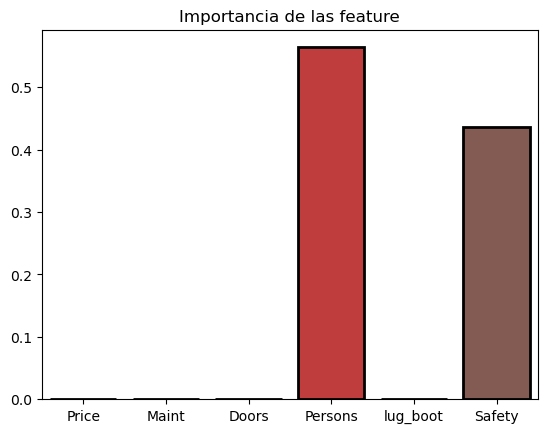

In [66]:
import seaborn as sns

importance = tree.feature_importances_
columns = x.columns
sns.barplot(x= columns, y = importance, edgecolor = "black", linewidth = 2)
plt.title("Importancia de las feature")


In [73]:
from sklearn.metrics import f1_score

score = f1_score(y_test,y_predict, average="micro")
score

0.7514450867052023

In [ ]:
#https://www.kaggle.com/datasets/kumargh/pimaindiansdiabetescsv

In [ ]:
df.columns = ['1. Number of times pregnant', '2. Plasma glucose concentration a 2 hours in an oral glucose tolerance test', '3. Diastolic blood pressure (mm Hg)', '4. Triceps skin fold thickness (mm)', '5. 2-Hour serum insulin (mu U/ml)', '6. Body mass index (weight in kg/(height in m)^2)', '7. Diabetes pedigree function', '8. Age (years)', '9. Class variable (0 or 1)']

En este conjunto de datos hay 8 características  de entrada y 1 característica de salida / destino / target. 

El significado de los nombres de las características es el siguiente:

* Número de embarazos.
* Concentración de glucosa en plasma a 2 horas en una prueba oral de tolerancia a la glucosa.
* Presión arterial diastólica (mm Hg).
* Espesor del pliegue cutáneo del tríceps (mm).
* Insulina sérica de 2 horas (mu U / ml).
* Índice de masa corporal (peso en kg / (altura en m) ^ 2).
* Función del pedigrí de la diabetes.
* Edad (años).
* Variable de clase (0 o 1).